In [ ]:
import pandas as pd
import numpy as np
import random
import networkx as nx
from tqdm import tqdm
import re
import matplotlib.pyplot as plt
# ============================================================
# IMPORT MACHINE LEARNING CLASSIFIERS
# ============================================================

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.naive_bayes import GaussianNB

from sklearn.svm import SVC

from xgboost import XGBClassifier

from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [ ]:
with open("/content/fb-pages-food.nodes",encoding='latin-1') as f:
    fb_nodes = f.read().splitlines()

# load edges (or links)
with open("/content/fb-pages-food.edges",encoding='latin-1') as f:
    fb_links = f.read().splitlines()

print("No of nodes=", len(fb_nodes))
print("No of nodes=",len(fb_links))


No of nodes= 623
No of nodes= 2102


In [ ]:
!pip install node2vec

In [ ]:


import tensorflow as tf
tf.test.gpu_device_name()

#This code checks whether TensorFlow can detect and use a GPU in the system or Google Colab environment.
#It helps verify if GPU acceleration is available for faster model training and computation. Empty String as output means no GPU is a

''

In [ ]:
# ============================================================
# LOAD EDGE DATASET
# ============================================================
fb_df = pd.read_csv(
    "/content/fb-pages-food.edges",
    names=['node_1', 'node_2']
)

print(fb_df.head())

print("\nDataset Shape:")
print(fb_df.shape)

   node_1  node_2
0       0     276
1       0      58
2       0     132
3       0     603
4       0     398

Dataset Shape:
(2102, 2)


In [ ]:
# ============================================================
# CREATE NETWORKX GRAPH
# ============================================================

G = nx.from_pandas_edgelist(
    fb_df,
    source='node_1',
    target='node_2',
    create_using=nx.Graph()
)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 620
Number of edges: 2102


Above code converts the edge list DataFrame fb_df into a NetworkX graph object. It creates an undirected graph where node_1 and node_2 columns represent connected nodes (edges),
and G stores the complete network structure for graph analysis and link prediction.

# Graph Node  → Numerical Index
Because graph nodes are labels
matrices use row/column numbers. So we need a connection between them.

In [ ]:
nodes = list(G.nodes())

node_index = {}

for idx, node in enumerate(nodes):
    node_index[node] = idx

print(node_index)
 # Graph Node  → Numerical Index

{0: 0, 276: 1, 58: 2, 132: 3, 603: 4, 398: 5, 555: 6, 1: 7, 265: 8, 611: 9, 2: 10, 182: 11, 345: 12, 3: 13, 608: 14, 377: 15, 40: 16, 352: 17, 450: 18, 484: 19, 299: 20, 65: 21, 185: 22, 228: 23, 557: 24, 227: 25, 90: 26, 151: 27, 394: 28, 4: 29, 287: 30, 254: 31, 336: 32, 5: 33, 503: 34, 6: 35, 429: 36, 163: 37, 486: 38, 478: 39, 518: 40, 7: 41, 293: 42, 305: 43, 339: 44, 35: 45, 444: 46, 583: 47, 8: 48, 278: 49, 434: 50, 73: 51, 98: 52, 369: 53, 9: 54, 317: 55, 288: 56, 206: 57, 289: 58, 249: 59, 593: 60, 550: 61, 131: 62, 446: 63, 89: 64, 15: 65, 340: 66, 248: 67, 229: 68, 56: 69, 570: 70, 189: 71, 107: 72, 23: 73, 465: 74, 67: 75, 351: 76, 498: 77, 10: 78, 393: 79, 258: 80, 11: 81, 212: 82, 485: 83, 264: 84, 380: 85, 174: 86, 259: 87, 12: 88, 548: 89, 618: 90, 310: 91, 13: 92, 14: 93, 326: 94, 70: 95, 454: 96, 505: 97, 43: 98, 432: 99, 16: 100, 516: 101, 119: 102, 400: 103, 545: 104, 334: 105, 237: 106, 374: 107, 117: 108, 274: 109, 613: 110, 466: 111, 75: 112, 17: 113, 18: 114, 40

In [ ]:
# ============================================================
# COMPUTE KATZ SIMILARITY MATRIX
# ============================================================

import numpy as np
from numpy.linalg import inv

# Convert graph to adjacency matrix
A = nx.to_numpy_array(G)

# Number of nodes
n = A.shape[0]

# Identity matrix
I = np.identity(n)

# Small alpha value for convergence
alpha = 0.005

# Katz similarity matrix
# Katz = (I - alpha*A)^-1 - I

katz_matrix = inv(I - alpha * A) - I

print("Katz similarity matrix shape:")
print(katz_matrix.shape)


Katz similarity matrix shape:
(620, 620)


In [ ]:
#CREATE WEIGHTED GRAPH USING KATZ SCORES

#This is the CORE INTEGRATION STEP.

#We replace ordinary graph edges with weighted edges.

G_weighted = nx.Graph()

for u, v in G.edges():

    i = node_index[u]
    j = node_index[v]

    katz_score = katz_matrix[i][j]

    # Add weighted edge
    G_weighted.add_edge(
        u,
        v,
        weight=float(katz_score)
    )

GENERATE NODE2VEC EMBEDDINGS USING WEIGHTED GRAPH

In [ ]:
from node2vec import Node2Vec
node2vec = Node2Vec(
    G_weighted,
    dimensions=64,
    walk_length=30,
    num_walks=200,
    workers=4,
    weight_key='weight'
)

Computing transition probabilities:   0%|          | 0/620 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# TRAIN NODE2VEC MODEL
# ============================================================

model = node2vec.fit(
    window=10,
    min_count=1,
    batch_words=4
)

print("Node2Vec model training completed.")

Node2Vec model training completed.


In [ ]:
# ============================================================
# CREATE POSITIVE EDGE SAMPLES
# ============================================================

positive_edges = []

for u, v in G.edges():
    positive_edges.append((u, v, 1))

print("Positive samples:", len(positive_edges))

Positive samples: 2102


In [ ]:
# ============================================================
# CREATE NEGATIVE EDGE SAMPLES
# ============================================================

negative_edges = []

nodes_list = list(G.nodes())

while len(negative_edges) < len(positive_edges):

    u = np.random.choice(nodes_list)
    v = np.random.choice(nodes_list)

    if u != v and not G.has_edge(u, v):

        negative_edges.append((u, v, 0))

print("Negative samples:", len(negative_edges))

Negative samples: 2102


In [ ]:
# ============================================================
# CREATE FINAL DATAFRAME
# ============================================================

all_edges = positive_edges + negative_edges

data = pd.DataFrame(
    all_edges,
    columns=['node_1', 'node_2', 'link']
)

print(data.head())

   node_1  node_2  link
0       0     276     1
1       0      58     1
2       0     132     1
3       0     603     1
4       0     398     1


In [ ]:
# ============================================================
# EDGE EMBEDDING FUNCTION
# ============================================================

def edge_embedding(u, v):

    emb_u = model.wv[str(u)]
    emb_v = model.wv[str(v)]

    # Hadamard Product
    return emb_u * emb_v



Here, wv means: word vectors, because node2vec is built on top of
Word2Vec from NLP.

In [ ]:
# ============================================================
# BUILD FEATURE MATRIX
# ============================================================

X = []

for _, row in data.iterrows():

    u = row['node_1']
    v = row['node_2']

    X.append(edge_embedding(u, v))

X = np.array(X)

y = data['link']

print("Feature matrix shape:", X.shape)

Feature matrix shape: (4204, 64)


In [ ]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 3363
Testing samples: 841


In [ ]:
# ============================================================
# TRAIN XGBOOST CLASSIFIER
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

print("XGBoost training completed.")

XGBoost training completed.


In [ ]:
# ============================================================
# PREDICTIONS
# ============================================================

y_pred = xgb_model.predict(X_test)

y_prob = xgb_model.predict_proba(X_test)[:, 1]

In [ ]:
# ============================================================
# EVALUATION METRICS
# ============================================================

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy Score:
0.9595719381688466

ROC-AUC Score:
0.9947750017019539

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.96       397
           1       0.94      0.98      0.96       444

    accuracy                           0.96       841
   macro avg       0.96      0.96      0.96       841
weighted avg       0.96      0.96      0.96       841


Confusion Matrix:
[[371  26]
 [  8 436]]


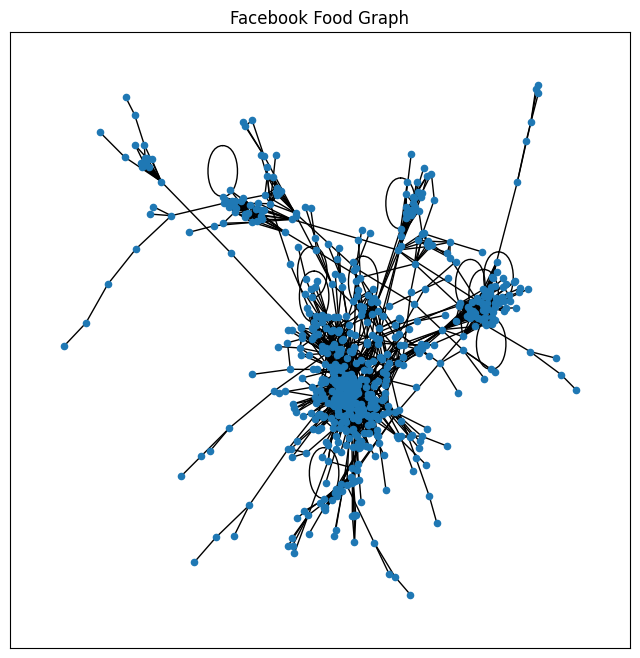

In [ ]:
# ============================================================
# OPTIONAL GRAPH VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

nx.draw_networkx(
    G,
    node_size=20,
    with_labels=False
)

plt.title("Facebook Food Graph")
plt.show()

In [ ]:
# ============================================================
# DEFINE ALL ORTHER CLASSIFIERS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Gaussian Naive Bayes": GaussianNB(),

    "Support Vector Machine": SVC(
        probability=True
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        eval_metric='logloss',
        random_state=42
    )
}

In [ ]:
# ============================================================
# TRAIN AND EVALUATE ALL CLASSIFIER MODELS
# ============================================================

results = []

for model_name, model in models.items():

    print("\n================================================")
    print("Model:", model_name)
    print("================================================")

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability scores
    y_prob = model.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    # Save results
    results.append([
        model_name,
        accuracy,
        roc_auc
    ])

    # Print metrics
    print("Accuracy:", accuracy)

    print("ROC-AUC:", roc_auc)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Model: Logistic Regression
Accuracy: 0.8870392390011891
ROC-AUC: 0.9510461342955046

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.83      0.87       397
           1       0.86      0.93      0.90       444

    accuracy                           0.89       841
   macro avg       0.89      0.88      0.89       841
weighted avg       0.89      0.89      0.89       841


Model: Random Forest
Accuracy: 0.9429250891795482
ROC-AUC: 0.9883671454830145

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       397
           1       0.95      0.94      0.95       444

    accuracy                           0.94       841
   macro avg       0.94      0.94      0.94       841
weighted avg       0.94      0.94      0.94       841


Model: Gaussian Naive Bayes
Accuracy: 0.6884661117717004
ROC-AUC: 0.8267042231148024

Classification Report:
              precision 

In [ ]:
# ============================================================
# MODEL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "ROC-AUC"
    ]
)

# Sort by ROC-AUC
results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

print(results_df)

                    Model  Accuracy   ROC-AUC
6                 XGBoost  0.956005  0.991320
5       Gradient Boosting  0.948870  0.990361
1           Random Forest  0.942925  0.988367
4                AdaBoost  0.936980  0.984546
3  Support Vector Machine  0.923900  0.980218
0     Logistic Regression  0.887039  0.951046
2    Gaussian Naive Bayes  0.688466  0.826704


Original Graph
      ↓
Katz Similarity Matrix
      ↓
Weighted Graph Construction
      ↓
Weighted node2vec Random Walks
      ↓
Node Embeddings
      ↓
Edge Embeddings
      ↓
XGBoost Classification
      ↓
Link Prediction